# Notebook 04: Federated Averaging (FedAvg)

## Objectives

This notebook implements the Federated Averaging (FedAvg) algorithm.

Unlike previous notebooks, this notebook is completely self-contained.

It will automatically:

- Verify GPU availability
- Download CIFAR-10 if missing
- Generate client partitions if unavailable
- Build the CNN model
- Simulate multiple federated clients
- Aggregate local model weights
- Evaluate the global model
- Save checkpoints and metrics

This design ensures reproducibility and allows the notebook to be executed independently.

In [4]:
import os
import copy
import pickle
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, Subset

import torchvision
import torchvision.transforms as transforms

In [5]:
# ============================================================
# ENVIRONMENT SETUP
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("="*60)
print("PyTorch :", torch.__version__)
print("Device  :", device)

if torch.cuda.is_available():
    print("GPU     :", torch.cuda.get_device_name(0))

print("="*60)

PyTorch : 2.11.0+cu128
Device  : cuda
GPU     : Tesla T4


In [6]:
# ============================================================
# LOAD OR DOWNLOAD CIFAR-10
# ============================================================

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914,0.4822,0.4465),
        (0.2023,0.1994,0.2010)
    )
])

print("Checking dataset...")

trainset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

classes = trainset.classes

print("="*60)
print("Training Images :",len(trainset))
print("Testing Images  :",len(testset))
print("="*60)

Checking dataset...


100%|██████████| 170M/170M [1:10:58<00:00, 40.0kB/s]


Training Images : 50000
Testing Images  : 10000


In [7]:
# ============================================================
# LOAD OR CREATE CLIENT PARTITIONS
# ============================================================

PARTITION_DIR = "saved_partitions"

os.makedirs(PARTITION_DIR, exist_ok=True)

IID_FILE = os.path.join(PARTITION_DIR,"iid_clients.pkl")

NONIID_FILE = os.path.join(PARTITION_DIR,"noniid_clients.pkl")

NUM_CLIENTS = 10
ALPHA = 0.3

if os.path.exists(IID_FILE) and os.path.exists(NONIID_FILE):

    print("Loading saved partitions...")

    with open(IID_FILE,"rb") as f:
        iid_clients = pickle.load(f)

    with open(NONIID_FILE,"rb") as f:
        noniid_clients = pickle.load(f)

else:

    print("Creating new partitions...")

    indices = np.random.permutation(len(trainset))

    iid_clients = np.array_split(indices,NUM_CLIENTS)

    def dirichlet_partition(targets,
                            num_clients,
                            alpha):

        targets=np.array(targets)

        client_indices=[[] for _ in range(num_clients)]

        for cls in np.unique(targets):

            cls_idx=np.where(targets==cls)[0]

            np.random.shuffle(cls_idx)

            proportions=np.random.dirichlet(
                np.repeat(alpha,num_clients)
            )

            split=np.split(
                cls_idx,
                (np.cumsum(proportions)*len(cls_idx)).astype(int)[:-1]
            )

            for i,idx in enumerate(split):
                client_indices[i].extend(idx)

        return client_indices

    noniid_clients = dirichlet_partition(
        trainset.targets,
        NUM_CLIENTS,
        ALPHA
    )

    with open(IID_FILE,"wb") as f:
        pickle.dump(iid_clients,f)

    with open(NONIID_FILE,"wb") as f:
        pickle.dump(noniid_clients,f)

print("="*60)
print("IID Clients     :",len(iid_clients))
print("NonIID Clients  :",len(noniid_clients))
print("="*60)

Creating new partitions...
IID Clients     : 10
NonIID Clients  : 10


In [8]:
# ============================================================
# CNN MODEL
# ============================================================

class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)

        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128*4*4,512),
            nn.ReLU(),

            nn.Linear(512,10)

        )

    def forward(self,x):

        x=self.features(x)

        x=self.classifier(x)

        return x

print(CNN())

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [9]:
# ============================================================
# INITIALIZE GLOBAL MODEL
# ============================================================

global_model = CNN().to(device)

print("="*60)
print("Global CNN initialized successfully.")
print("="*60)

Global CNN initialized successfully.


In [10]:
# ============================================================
# MODEL EVALUATION
# ============================================================

def evaluate(model, loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            predictions = outputs.argmax(dim=1)

            total += labels.size(0)

            correct += (predictions == labels).sum().item()

    accuracy = 100 * correct / total

    return accuracy

In [11]:
# ============================================================
# LOCAL CLIENT TRAINING
# ============================================================

def local_train(model,
                trainloader,
                epochs=1,
                lr=0.001):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr
    )

    model.train()

    for epoch in range(epochs):

        running_loss = 0

        for images, labels in trainloader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

    return model.state_dict()

In [12]:
# ============================================================
# CREATE CLIENT DATALOADERS
# ============================================================

client_loaders = []

for client_id in range(NUM_CLIENTS):

    subset = Subset(trainset, iid_clients[client_id])

    loader = DataLoader(
        subset,
        batch_size=64,
        shuffle=True
    )

    client_loaders.append(loader)

print("="*60)
print("Created", len(client_loaders), "client dataloaders.")
print("="*60)

Created 10 client dataloaders.


In [13]:
# ============================================================
# FEDERATED AVERAGING
# ============================================================

def federated_average(client_weights):

    global_weights = copy.deepcopy(client_weights[0])

    for key in global_weights.keys():

        for i in range(1, len(client_weights)):

            global_weights[key] += client_weights[i][key]

        global_weights[key] = torch.div(
            global_weights[key],
            len(client_weights)
        )

    return global_weights

In [14]:
# ============================================================
# TEST DATALOADER
# ============================================================

testloader = DataLoader(
    testset,
    batch_size=128,
    shuffle=False
)

print("Test DataLoader Ready!")

Test DataLoader Ready!


In [15]:
# ============================================================
# FEDERATED TRAINING CONFIGURATION
# ============================================================

ROUNDS = 10
LOCAL_EPOCHS = 1

global_accuracy = []

print("="*60)
print("Communication Rounds :", ROUNDS)
print("Local Epochs         :", LOCAL_EPOCHS)
print("="*60)

Communication Rounds : 10
Local Epochs         : 1


In [16]:
# ============================================================
# FEDERATED TRAINING
# ============================================================

for rnd in range(ROUNDS):

    print(f"\nCommunication Round {rnd+1}/{ROUNDS}")

    client_weights = []

    for client_id in range(NUM_CLIENTS):

        local_model = copy.deepcopy(global_model)

        weights = local_train(
            local_model,
            client_loaders[client_id],
            epochs=LOCAL_EPOCHS
        )

        client_weights.append(weights)

    averaged_weights = federated_average(client_weights)

    global_model.load_state_dict(averaged_weights)

    accuracy = evaluate(global_model, testloader)

    global_accuracy.append(accuracy)

    print(f"Global Accuracy : {accuracy:.2f}%")


Communication Round 1/10
Global Accuracy : 41.58%

Communication Round 2/10
Global Accuracy : 49.40%

Communication Round 3/10
Global Accuracy : 54.29%

Communication Round 4/10
Global Accuracy : 56.91%

Communication Round 5/10
Global Accuracy : 61.02%

Communication Round 6/10
Global Accuracy : 63.44%

Communication Round 7/10
Global Accuracy : 65.60%

Communication Round 8/10
Global Accuracy : 67.23%

Communication Round 9/10
Global Accuracy : 68.48%

Communication Round 10/10
Global Accuracy : 69.84%


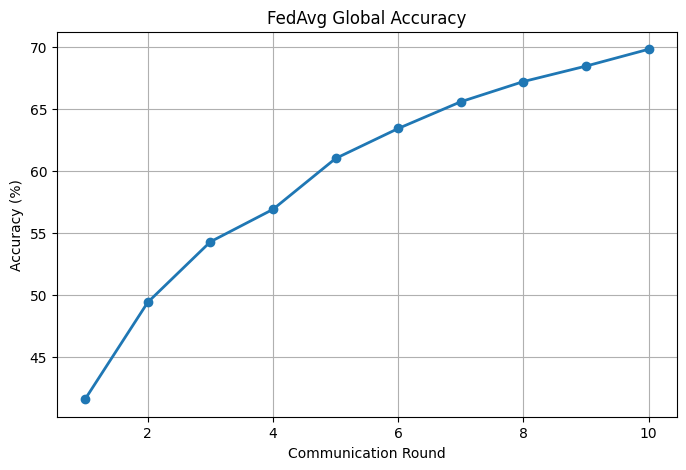

In [17]:
# ============================================================
# GLOBAL ACCURACY CURVE
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    range(1,ROUNDS+1),
    global_accuracy,
    marker="o",
    linewidth=2
)

plt.xlabel("Communication Round")
plt.ylabel("Accuracy (%)")
plt.title("FedAvg Global Accuracy")

plt.grid(True)

plt.show()

In [18]:
# ============================================================
# SAVE GLOBAL MODEL
# ============================================================

SAVE_DIR = "saved_models"

os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_PATH = os.path.join(
    SAVE_DIR,
    "fedavg_global_model.pth"
)

torch.save(
    global_model.state_dict(),
    MODEL_PATH
)

print("="*60)
print("Global model saved successfully!")
print(MODEL_PATH)
print("="*60)

Global model saved successfully!
saved_models/fedavg_global_model.pth


In [19]:
# ============================================================
# SAVE TRAINING METRICS
# ============================================================

import pandas as pd

RESULT_DIR = "results"

os.makedirs(RESULT_DIR, exist_ok=True)

metrics = pd.DataFrame({

    "Round": range(1,ROUNDS+1),
    "Accuracy": global_accuracy

})

CSV_PATH = os.path.join(
    RESULT_DIR,
    "fedavg_metrics.csv"
)

metrics.to_csv(
    CSV_PATH,
    index=False
)

print(metrics)

print("\nMetrics saved to:")
print(CSV_PATH)

   Round  Accuracy
0      1     41.58
1      2     49.40
2      3     54.29
3      4     56.91
4      5     61.02
5      6     63.44
6      7     65.60
7      8     67.23
8      9     68.48
9     10     69.84

Metrics saved to:
results/fedavg_metrics.csv


In [20]:
# ============================================================
# FINAL RESULTS
# ============================================================

print("="*60)
print("FEDERATED LEARNING COMPLETED")
print("="*60)

print(f"Clients              : {NUM_CLIENTS}")
print(f"Communication Rounds : {ROUNDS}")
print(f"Local Epochs         : {LOCAL_EPOCHS}")

print(f"\nFinal Global Accuracy : {global_accuracy[-1]:.2f}%")

print("="*60)

FEDERATED LEARNING COMPLETED
Clients              : 10
Communication Rounds : 10
Local Epochs         : 1

Final Global Accuracy : 69.84%
